Step-by-Step Approach to EDA

step 1 load Necessary Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# step 2 loading daset

In [38]:
from google.colab import files
uploaded = files.upload()

Saving titanic.zip to titanic (1).zip


Step 3 Extract the Uploaded ZIP File

In [40]:
import zipfile
import os

# get file name
zip_file = list(uploaded.keys())[0]

# extract
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

# check contents
os.listdir('/content/data')

['gender_submission.csv', 'train.csv', 'test.csv']

In [41]:
import pandas as pd

df = pd.read_csv('/content/data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step 4 Understand the Dataset Columns

| Column   | Meaning                      |
| -------- | ---------------------------- |
| Survived | 0 = No, 1 = Yes              |
| Pclass   | Ticket class (1st, 2nd, 3rd) |
| Sex      | Male/Female                  |
| Age      | Passenger age                |
| Fare     | Ticket price                 |
| Embarked | Port (C, Q, S)       **bold text**        |
# New Section

# Step Data preprocessing

In [42]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Step 6 Perform data cleaning

### Handling Missing Values

In [16]:
# Fill missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing 'Embarked' values with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop the 'Cabin' column due to a high number of missing values
df.drop('Cabin', axis=1, inplace=True)

# Verify that there are no more missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_516/1102652239.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_516/1102652239.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

 Step 7 Compute basic statistics, visualize distributions, and generate initial insights.



--- General Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353

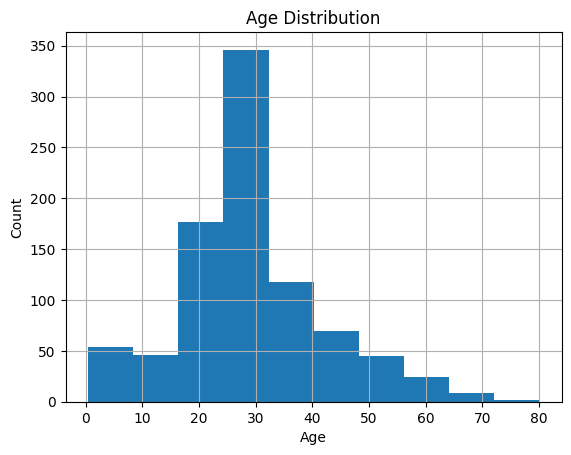


--- Survival Count ---
Survived
0    549
1    342
Name: count, dtype: int64


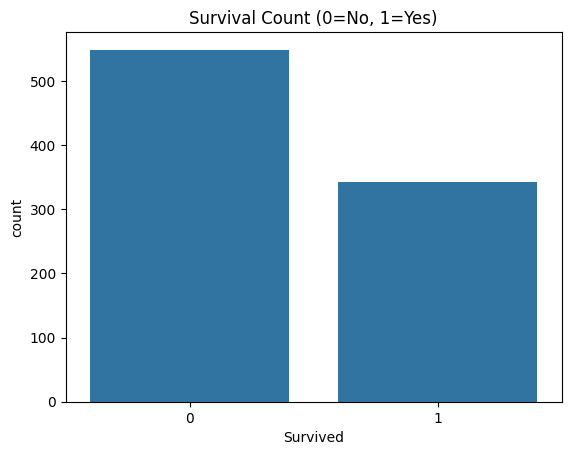


--- Sex Distribution ---
Sex
male      577
female    314
Name: count, dtype: int64


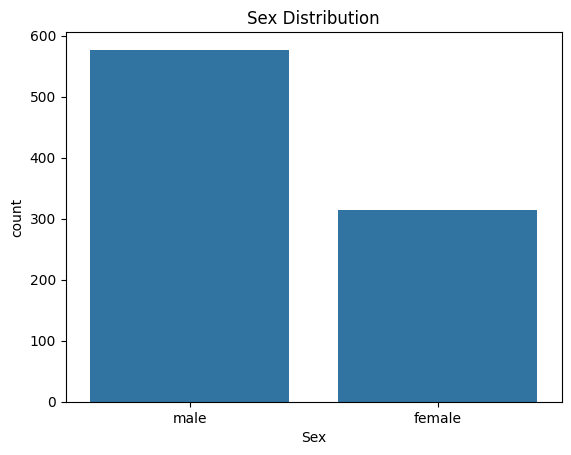


--- Pclass Distribution ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


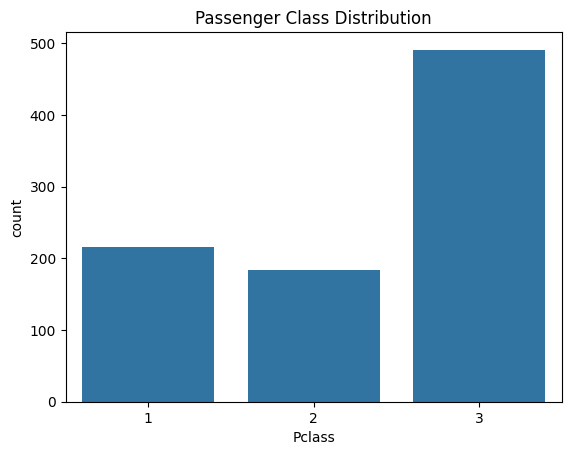


--- Embarked Distribution ---
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


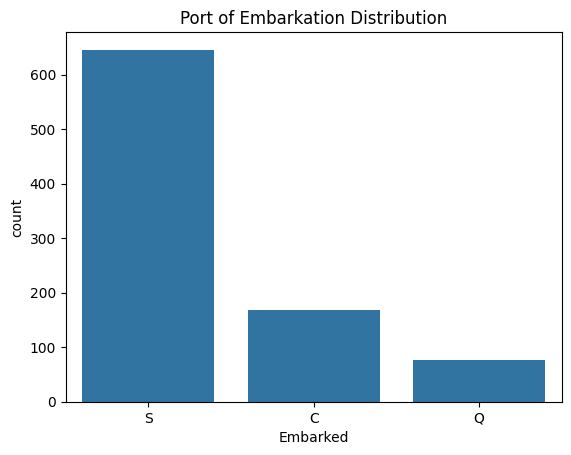


--- Fare Distribution ---


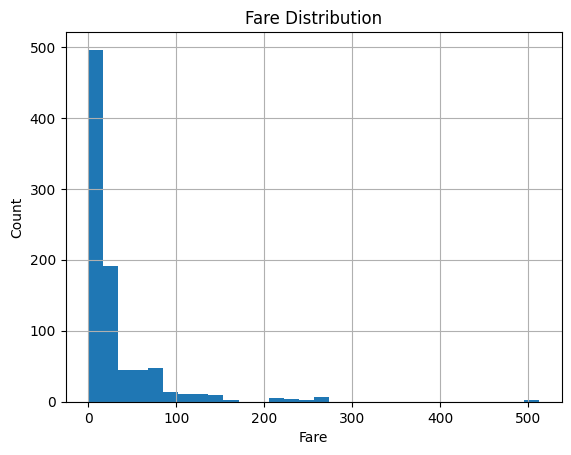

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- General Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Age Distribution ---")
df['Age'].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

print("\n--- Survival Count ---")
print(df['Survived'].value_counts())
sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0=No, 1=Yes)')
plt.show()

print("\n--- Sex Distribution ---")
print(df['Sex'].value_counts())
sns.countplot(x='Sex', data=df)
plt.title('Sex Distribution')
plt.show()

print("\n--- Pclass Distribution ---")
print(df['Pclass'].value_counts())
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

print("\n--- Embarked Distribution ---")
print(df['Embarked'].value_counts())
sns.countplot(x='Embarked', data=df)
plt.title('Port of Embarkation Distribution')
plt.show()

print("\n--- Fare Distribution ---")
df['Fare'].hist(bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

Step 8 Intermediate Analysis
   - Explore correlations, patterns, and relationships among features.
   - Create visualizations to support findings and explore data interactions.


In [20]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [21]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Step 8 Advanced Analysis
   - Utilize advanced visualization techniques and multivariate analysis to uncover deeper insights.
   



Correlation Heatmap

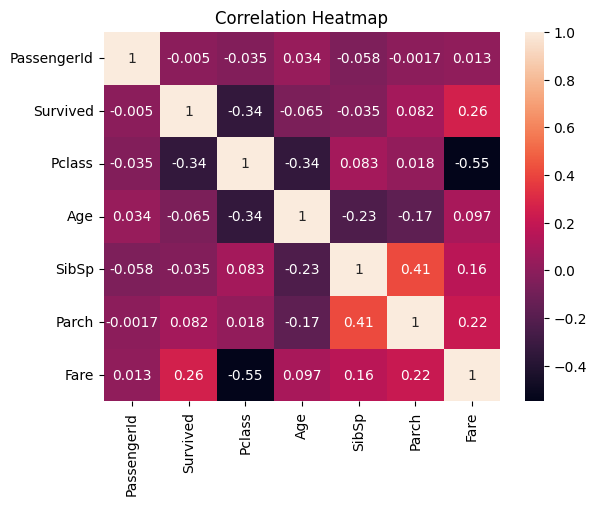

In [24]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Pairplot (Multivariate Relationships)

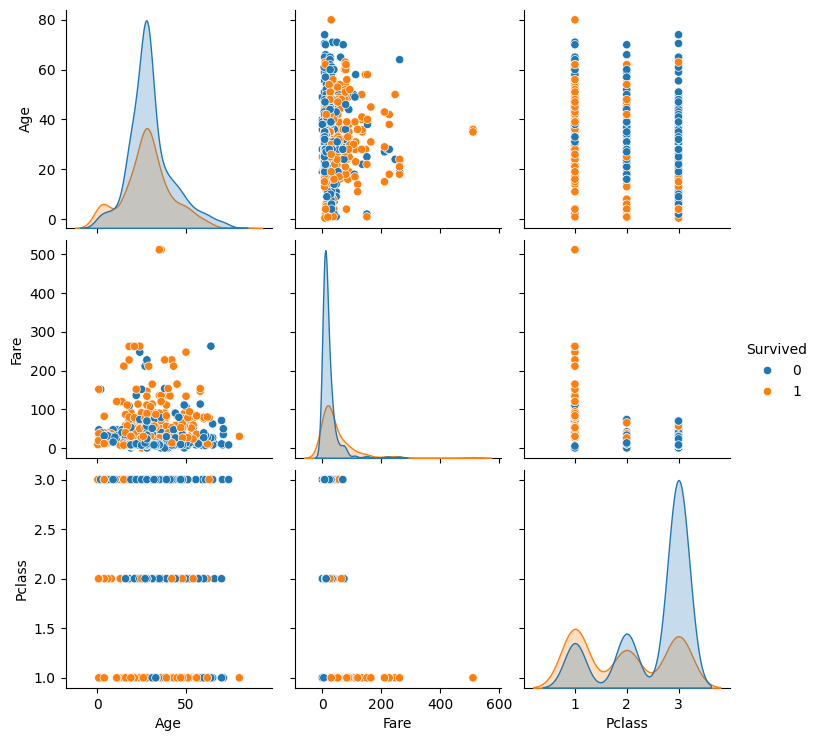

In [25]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']], hue='Survived')
plt.show()

Survival by Gender & Class

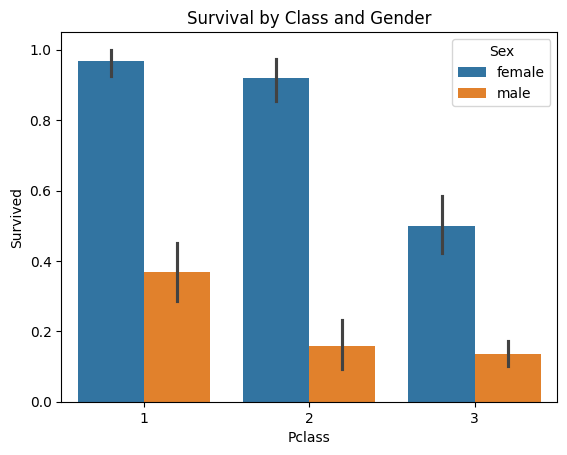

In [26]:
plt.figure()
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title("Survival by Class and Gender")
plt.show()

Age Distribution by Survival

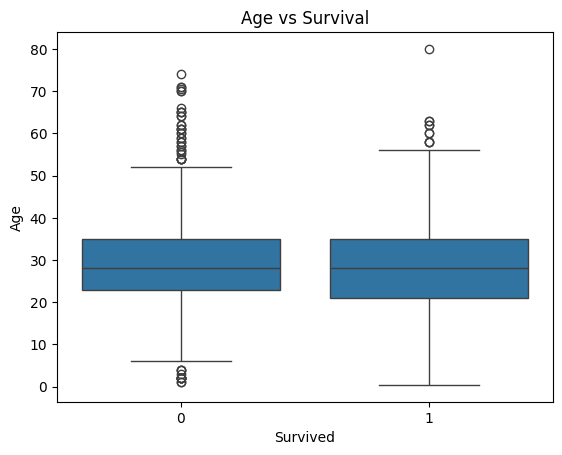

In [27]:
plt.figure()
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

Fare Distribution by Class

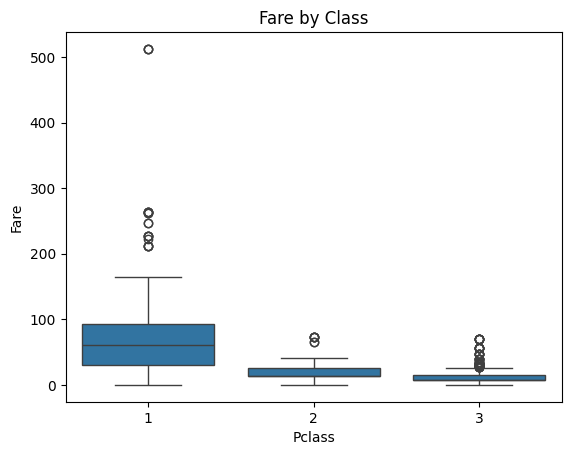

In [28]:
plt.figure()
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare by Class")
plt.show()

 Implement predictive modeling to predict survival.


Define Features & Target

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

Define Features & Target

In [30]:
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
y = df['Survived']

Train/Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions & Evaluation

In [33]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

